#### LSTM for volatility forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

ftse = pd.read_csv('data/ftse_processed.csv', index_col='Date', parse_dates=True)
sp500 = pd.read_csv('data/sp500_processed.csv', index_col='Date', parse_dates=True)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
ftse.head()

PyTorch version: 2.13.0+cpu
CUDA available: False


,Close,High,Low,Open,Volume,log_return,volatility_21d,volatility_annualized
Date,,,,,,,,
2015-01-05,6417.200195,6576.700195,6404.500000,6547.799805,728001100,-0.020147,NaN,NaN
2015-01-06,6366.500000,6452.700195,6328.600098,6417.200195,769463100,-0.007932,NaN,NaN
2015-01-07,6419.799805,6459.700195,6366.500000,6366.500000,688211500,0.008337,NaN,NaN
2015-01-08,6570.000000,6580.799805,6419.799805,6419.799805,882740200,0.023127,NaN,NaN
2015-01-09,6501.100098,6570.200195,6471.399902,6570.000000,738488500,-0.010542,NaN,NaN


In [2]:
#Preparing data and building the windowing function

# Drop rows with NaN volatility (the first 20 days, before the rolling window fills)
ftse_clean = ftse.dropna(subset=['volatility_annualized']).copy()
sp500_clean = sp500.dropna(subset=['volatility_annualized']).copy()

print("FTSE clean shape:", ftse_clean.shape)
print("S&P 500 clean shape:", sp500_clean.shape)

FTSE clean shape: (2904, 8)
S&P 500 clean shape: (2890, 8)


In [3]:
def create_sequences(data, seq_length=21):
    """
    Turns a 1D array into (X, y) pairs for LSTM training.
    X: sequences of `seq_length` past values
    y: the single next value to predict
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Test it on a tiny example first, so you can SEE what it does
test_data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
X_test, y_test = create_sequences(test_data, seq_length=3)
print("X_test:\n", X_test)
print("y_test:\n", y_test)

X_test:
 [[1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]
 [6 7 8]
 [7 8 9]]
y_test:
 [ 4  5  6  7  8  9 10]


In [4]:
#Applying windowing to real volatility data

# Extract just the volatility column as a 1D array
ftse_vol = ftse_clean['volatility_annualized'].values
sp500_vol = sp500_clean['volatility_annualized'].values

# Create sequences with a 21-day window (matches your GARCH/realized vol convention)
SEQ_LENGTH = 21

X_ftse, y_ftse = create_sequences(ftse_vol, SEQ_LENGTH)
X_sp500, y_sp500 = create_sequences(sp500_vol, SEQ_LENGTH)

print("FTSE X shape:", X_ftse.shape, "| y shape:", y_ftse.shape)
print("S&P 500 X shape:", X_sp500.shape, "| y shape:", y_sp500.shape)

FTSE X shape: (2883, 21) | y shape: (2883,)
S&P 500 X shape: (2869, 21) | y shape: (2869,)


In [5]:
#Scaling the data for LSTM

from sklearn.preprocessing import MinMaxScaler

# Fit a separate scaler per index — FTSE and S&P 500 have different volatility ranges
scaler_ftse = MinMaxScaler()
scaler_sp500 = MinMaxScaler()

# Scaler expects 2D input, so reshape
X_ftse_scaled = scaler_ftse.fit_transform(X_ftse.reshape(-1, 1)).reshape(X_ftse.shape)
y_ftse_scaled = scaler_ftse.transform(y_ftse.reshape(-1, 1)).flatten()

X_sp500_scaled = scaler_sp500.fit_transform(X_sp500.reshape(-1, 1)).reshape(X_sp500.shape)
y_sp500_scaled = scaler_sp500.transform(y_sp500.reshape(-1, 1)).flatten()

print("Scaled FTSE X range:", X_ftse_scaled.min(), "to", X_ftse_scaled.max())

Scaled FTSE X range: 0.0 to 0.9999999999999999


In [6]:
#Train/test split

def train_test_split_timeseries(X, y, test_ratio=0.2):
    split_idx = int(len(X) * (1 - test_ratio))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    return X_train, X_test, y_train, y_test

X_train_ftse, X_test_ftse, y_train_ftse, y_test_ftse = train_test_split_timeseries(X_ftse_scaled, y_ftse_scaled)
X_train_sp500, X_test_sp500, y_train_sp500, y_test_sp500 = train_test_split_timeseries(X_sp500_scaled, y_sp500_scaled)

print("FTSE train:", X_train_ftse.shape, "| test:", X_test_ftse.shape)

FTSE train: (2306, 21) | test: (577, 21)


In [7]:
print("S&P 500 train:", X_train_sp500.shape, "| test:", X_test_sp500.shape)

S&P 500 train: (2295, 21) | test: (574, 21)


In [8]:
#Converting to PyTorch tensors

def to_tensor(X, y):
    # LSTM expects input shape: (batch_size, sequence_length, num_features)
    # We have 1 feature (volatility), so we add that dimension with unsqueeze
    X_tensor = torch.FloatTensor(X).unsqueeze(-1)
    y_tensor = torch.FloatTensor(y).unsqueeze(-1)
    return X_tensor, y_tensor

X_train_ftse_t, y_train_ftse_t = to_tensor(X_train_ftse, y_train_ftse)
X_test_ftse_t, y_test_ftse_t = to_tensor(X_test_ftse, y_test_ftse)

X_train_sp500_t, y_train_sp500_t = to_tensor(X_train_sp500, y_train_sp500)
X_test_sp500_t, y_test_sp500_t = to_tensor(X_test_sp500, y_test_sp500)

print("FTSE train tensor shape:", X_train_ftse_t.shape)

FTSE train tensor shape: torch.Size([2306, 21, 1])


In [9]:
#Defining the LSTM model

class VolatilityLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # We only care about the LAST timestep's output — that's our prediction
        last_output = lstm_out[:, -1, :]
        prediction = self.fc(last_output)
        return prediction

model_ftse = VolatilityLSTM()
model_sp500 = VolatilityLSTM()
print(model_ftse)

VolatilityLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [10]:
#The Training Loop

def train_model(model, X_train, y_train, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        predictions = model(X_train)
        loss = criterion(predictions, y_train)
        
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")
    
    return losses

print("Training FTSE model...")
losses_ftse = train_model(model_ftse, X_train_ftse_t, y_train_ftse_t)

Training FTSE model...
Epoch 20/100, Loss: 0.012875
Epoch 40/100, Loss: 0.010969
Epoch 60/100, Loss: 0.008823
Epoch 80/100, Loss: 0.005089
Epoch 100/100, Loss: 0.002479


In [11]:
#Training the S&P 500 model

print("Training S&P 500 model...")
losses_sp500 = train_model(model_sp500, X_train_sp500_t, y_train_sp500_t)

Training S&P 500 model...
Epoch 20/100, Loss: 0.025729
Epoch 40/100, Loss: 0.011702
Epoch 60/100, Loss: 0.009311
Epoch 80/100, Loss: 0.007511
Epoch 100/100, Loss: 0.004750


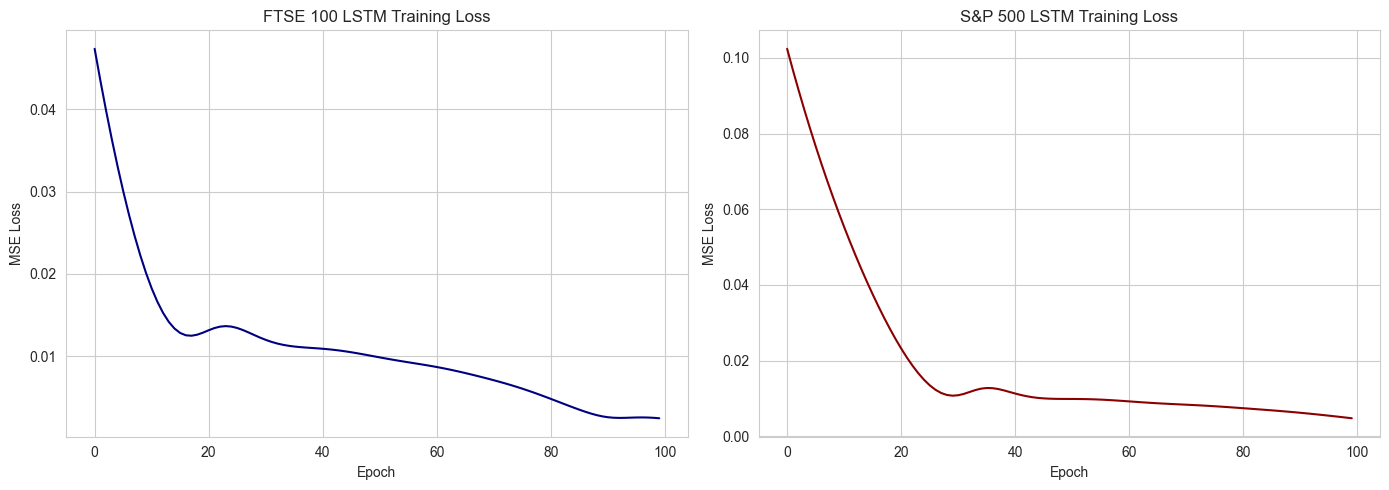

In [12]:
#Visualizing both loss curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(losses_ftse, color='navy')
axes[0].set_title('FTSE 100 LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')

axes[1].plot(losses_sp500, color='darkred')
axes[1].set_title('S&P 500 LSTM Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')

plt.tight_layout()
plt.show()

In [13]:
#Evaluating the models on the test set

def evaluate_model(model, X_test, y_test, scaler):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test)
    
    # Convert back to original scale (undo the 0-1 scaling) so numbers are interpretable
    predictions_actual = scaler.inverse_transform(predictions.numpy())
    y_test_actual = scaler.inverse_transform(y_test.numpy())
    
    mse = np.mean((predictions_actual - y_test_actual) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions_actual - y_test_actual))
    
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    
    return predictions_actual, y_test_actual

print("--- FTSE 100 Test Performance ---")
pred_ftse, actual_ftse = evaluate_model(model_ftse, X_test_ftse_t, y_test_ftse_t, scaler_ftse)

print("\n--- S&P 500 Test Performance ---")
pred_sp500, actual_sp500 = evaluate_model(model_sp500, X_test_sp500_t, y_test_sp500_t, scaler_sp500)

--- FTSE 100 Test Performance ---
Test RMSE: 0.0278
Test MAE: 0.0189

--- S&P 500 Test Performance ---
Test RMSE: 0.0513
Test MAE: 0.0375


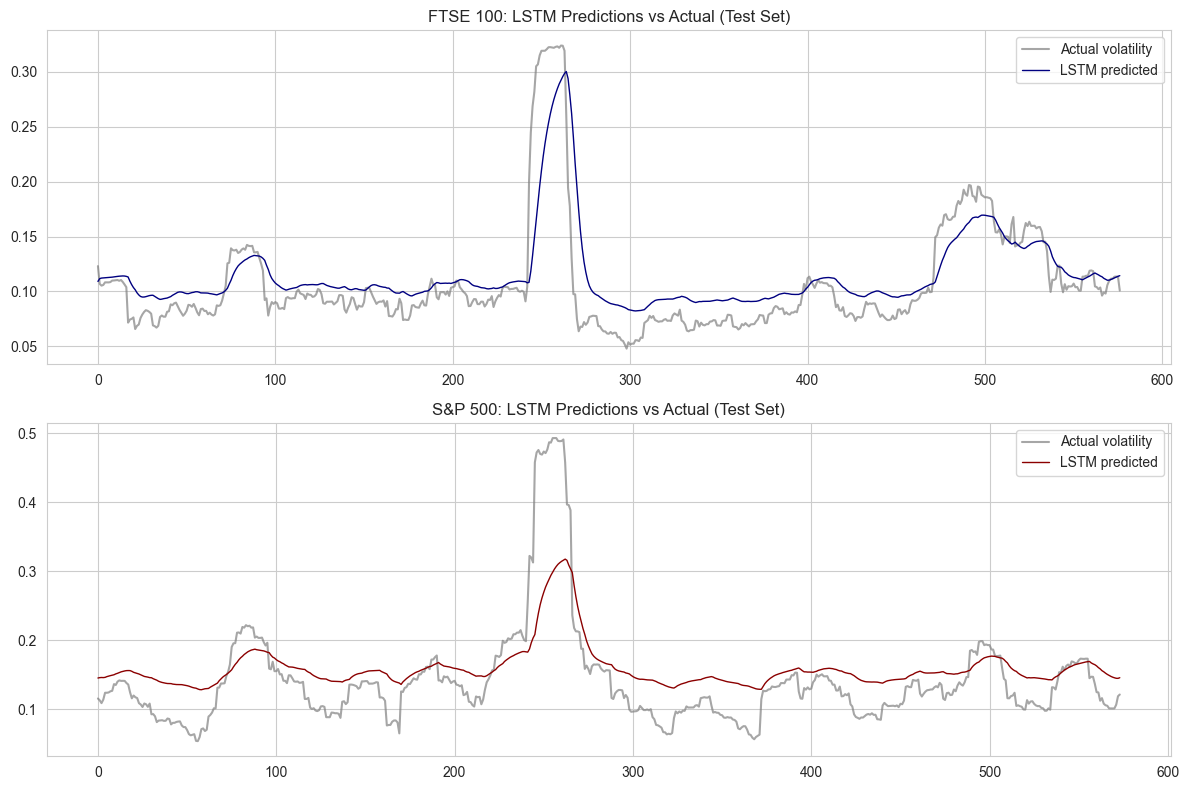

In [14]:
#Visualizing predictions vs actual volatility for both indices

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(actual_ftse, label='Actual volatility', color='gray', alpha=0.7)
axes[0].plot(pred_ftse, label='LSTM predicted', color='navy', linewidth=1)
axes[0].set_title('FTSE 100: LSTM Predictions vs Actual (Test Set)')
axes[0].legend()

axes[1].plot(actual_sp500, label='Actual volatility', color='gray', alpha=0.7)
axes[1].plot(pred_sp500, label='LSTM predicted', color='darkred', linewidth=1)
axes[1].set_title('S&P 500: LSTM Predictions vs Actual (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
print("Retraining FTSE model with more epochs...")
model_ftse_v2 = VolatilityLSTM()
losses_ftse_v2 = train_model(model_ftse_v2, X_train_ftse_t, y_train_ftse_t, epochs=200)

print("\n--- FTSE 100 v2 Test Performance ---")
pred_ftse_v2, actual_ftse_v2 = evaluate_model(model_ftse_v2, X_test_ftse_t, y_test_ftse_t, scaler_ftse)

Retraining FTSE model with more epochs...
Epoch 20/200, Loss: 0.011532
Epoch 40/200, Loss: 0.009959
Epoch 60/200, Loss: 0.008532
Epoch 80/200, Loss: 0.006177
Epoch 100/200, Loss: 0.002589
Epoch 120/200, Loss: 0.002178
Epoch 140/200, Loss: 0.001915
Epoch 160/200, Loss: 0.001703
Epoch 180/200, Loss: 0.001510
Epoch 200/200, Loss: 0.001328

--- FTSE 100 v2 Test Performance ---
Test RMSE: 0.0229
Test MAE: 0.0136


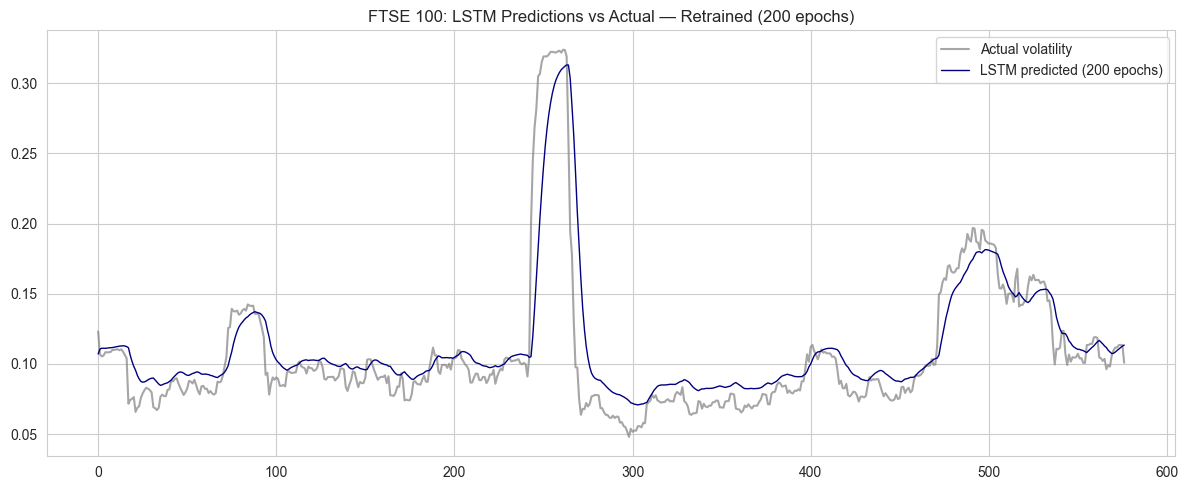

In [16]:
#Visualizing version 2 predictions vs actual volatility for FTSE

plt.figure(figsize=(12, 5))
plt.plot(actual_ftse_v2, label='Actual volatility', color='gray', alpha=0.7)
plt.plot(pred_ftse_v2, label='LSTM predicted (200 epochs)', color='navy', linewidth=1)
plt.title('FTSE 100: LSTM Predictions vs Actual — Retrained (200 epochs)')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
#swap version 2 as  official FTSE model
model_ftse = model_ftse_v2
pred_ftse = pred_ftse_v2
actual_ftse = actual_ftse_v2
losses_ftse = losses_ftse_v2

In [18]:
print("Retraining S&P 500 model with more epochs for fair comparison...")
model_sp500_v2 = VolatilityLSTM()
losses_sp500_v2 = train_model(model_sp500_v2, X_train_sp500_t, y_train_sp500_t, epochs=200)

print("\n--- S&P 500 v2 Test Performance ---")
pred_sp500_v2, actual_sp500_v2 = evaluate_model(model_sp500_v2, X_test_sp500_t, y_test_sp500_t, scaler_sp500)

Retraining S&P 500 model with more epochs for fair comparison...
Epoch 20/200, Loss: 0.010693
Epoch 40/200, Loss: 0.008054
Epoch 60/200, Loss: 0.002150
Epoch 80/200, Loss: 0.001689
Epoch 100/200, Loss: 0.001268
Epoch 120/200, Loss: 0.000950
Epoch 140/200, Loss: 0.000598
Epoch 160/200, Loss: 0.000513
Epoch 180/200, Loss: 0.000475
Epoch 200/200, Loss: 0.000446

--- S&P 500 v2 Test Performance ---
Test RMSE: 0.0217
Test MAE: 0.0127


In [19]:
#Swap version 2 as official S&P 500 model
model_sp500 = model_sp500_v2
pred_sp500 = pred_sp500_v2
actual_sp500 = actual_sp500_v2
losses_sp500 = losses_sp500_v2

In [20]:
# Save LSTM predictions and actuals for use in the comparison notebook
np.save('data/pred_ftse.npy', pred_ftse)
np.save('data/actual_ftse.npy', actual_ftse)
np.save('data/pred_sp500.npy', pred_sp500)
np.save('data/actual_sp500.npy', actual_sp500)
print("LSTM predictions saved.")

LSTM predictions saved.


In [21]:
import torch
import joblib

# Save model weights
torch.save(model_ftse.state_dict(), 'data/model_ftse.pth')
torch.save(model_sp500.state_dict(), 'data/model_sp500.pth')

# Save the scalers too — needed to un-scale predictions later
joblib.dump(scaler_ftse, 'data/scaler_ftse.pkl')
joblib.dump(scaler_sp500, 'data/scaler_sp500.pkl')

print("Models and scalers saved.")

Models and scalers saved.
